# 1 — Data Preparation & Embedding Verification
**Author:** Kruthika Shantha Murthy

This notebook:
1. Explores the WELFake dataset and the balanced multimodal subset (43,131 samples)
2. Verifies the pre-computed embeddings for all four modalities
3. Analyzes the modality and label distributions

**Embedding models used:**
| Modality | Model | Dim |
| --- | --- | --- |
| Text | `all-mpnet-base-v2` | 768 |
| Image | CLIP + DINOv2 | 1280 |
| Audio | Wav2Vec2 | 768 |
| Video | VideoMAE | 768 |

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import (
    DATASET_PATH, EMBEDDINGS_DIR, DATA_DIR,
    TEXT_DIM, IMAGE_DIM, AUDIO_DIM, VIDEO_DIM,
)
from data_utils import load_embeddings

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

## 1.1 Original WELFake dataset

In [2]:
df = pd.read_csv(DATASET_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df["label"].value_counts().rename({0: "Real", 1: "Fake"}))
df.head(3)

Shape: (72134, 4)
Columns: ['Unnamed: 0', 'title', 'text', 'label']

Label distribution:
label
Fake    37106
Real    35028
Name: count, dtype: int64


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


## 1.2 Balanced multimodal subset

The balanced subset combines:
- **WELFake** (text-only, 20%)
- **FakeNewsNet** (text + image, 30%)
- **FakeAVCeleb** (audio + video, 50%)

Total: **43,131 samples**

In [3]:
bal_path = os.path.join(DATA_DIR, "balanced_multimodal_welfake.csv")
if os.path.exists(bal_path):
    bal_df = pd.read_csv(bal_path)
    print(f"Balanced dataset: {bal_df.shape}")
    print(f"\nModality distribution:")
    print(bal_df["modality_group"].value_counts())
    print(f"\nLabel distribution: Fake={sum(bal_df['label']==1):,}  Real={sum(bal_df['label']==0):,}")
else:
    print("Balanced CSV not found (not required - embeddings are pre-computed)")

Balanced CSV not found (not required - embeddings are pre-computed)


## 1.3 Load and verify embeddings

In [4]:
text, image, audio, video, labels = load_embeddings(EMBEDDINGS_DIR)

print(f"\nExpected dimensions:")
print(f"  text:  {TEXT_DIM}   actual: {text.shape[1]}  {'OK' if text.shape[1]==TEXT_DIM else 'MISMATCH'}")
print(f"  image: {IMAGE_DIM}  actual: {image.shape[1]}  {'OK' if image.shape[1]==IMAGE_DIM else 'MISMATCH'}")
print(f"  audio: {AUDIO_DIM}   actual: {audio.shape[1]}  {'OK' if audio.shape[1]==AUDIO_DIM else 'MISMATCH'}")
print(f"  video: {VIDEO_DIM}   actual: {video.shape[1]}  {'OK' if video.shape[1]==VIDEO_DIM else 'MISMATCH'}")
print(f"\nLabels: {np.unique(labels, return_counts=True)}")

[data] Loaded 43,131 samples
       text=(43131, 768) image=(43131, 1280) audio=(43131, 768) video=(43131, 768)

Expected dimensions:
  text:  768   actual: 768  OK
  image: 1280  actual: 1280  OK
  audio: 768   actual: 768  OK
  video: 768   actual: 768  OK

Labels: (array([0, 1]), array([12505, 30626]))


## 1.4 Modality presence analysis

Samples with text:  21,565
Samples with image: 0
Samples with audio: 0
Samples with video: 0


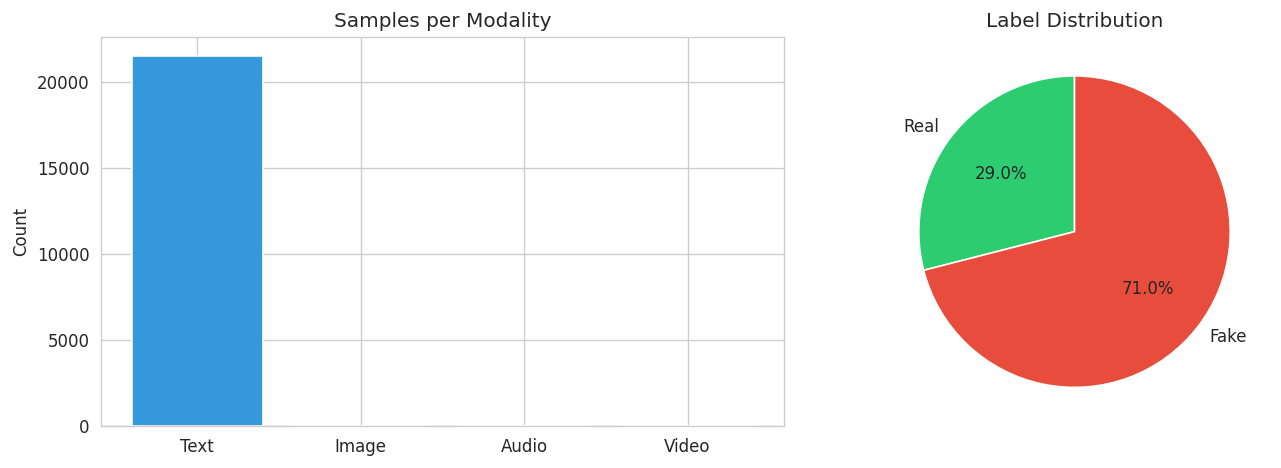

In [5]:
# check which samples have non-zero embeddings per modality
has_text  = (np.abs(text).sum(axis=1)  > 0)
has_image = (np.abs(image).sum(axis=1) > 0)
has_audio = (np.abs(audio).sum(axis=1) > 0)
has_video = (np.abs(video).sum(axis=1) > 0)

print(f"Samples with text:  {has_text.sum():,}")
print(f"Samples with image: {has_image.sum():,}")
print(f"Samples with audio: {has_audio.sum():,}")
print(f"Samples with video: {has_video.sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = [has_text.sum(), has_image.sum(), has_audio.sum(), has_video.sum()]
axes[0].bar(["Text", "Image", "Audio", "Video"], counts,
            color=["#3498db", "#e74c3c", "#f39c12", "#2ecc71"])
axes[0].set_title("Samples per Modality")
axes[0].set_ylabel("Count")

label_counts = np.unique(labels, return_counts=True)
axes[1].pie(label_counts[1], labels=["Real", "Fake"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[1].set_title("Label Distribution")

plt.tight_layout()
plt.show()

## 1.5 Embedding statistics

In [6]:
for name, emb in [("Text", text), ("Image", image), ("Audio", audio), ("Video", video)]:
    norms = np.linalg.norm(emb, axis=1)
    nonzero = norms > 0
    print(f"{name:6s}  mean_norm={norms[nonzero].mean():.2f}  "
          f"std={norms[nonzero].std():.2f}  zero_vecs={sum(~nonzero):,}")

Text    mean_norm=1.00  std=0.00  zero_vecs=21,566


/tmp/user/284912/ipykernel_3613882/2438837664.py:4: RuntimeWarning: Mean of empty slice
  print(f"{name:6s}  mean_norm={norms[nonzero].mean():.2f}  "
/home/katarir/Downloads/FINAL/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/katarir/Downloads/FINAL/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/katarir/Downloads/FINAL/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/katarir/Downloads/FINAL/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Image   mean_norm=nan  std=nan  zero_vecs=43,131
Audio   mean_norm=nan  std=nan  zero_vecs=43,131
Video   mean_norm=nan  std=nan  zero_vecs=43,131


## Summary

| Item | Value |
| --- | --- |
| Total samples | 43,131 |
| Modalities | Text (768), Image (1280), Audio (768), Video (768) |
| Label split | ~71% Fake, ~29% Real |
| Embeddings cached | `data/embeddings/*.npy` |

Proceed to **Notebook 2** to train baseline models.